In [1]:
import math
from datetime import timedelta
from operator import attrgetter

import matplotlib.pyplot as plt
import numpy as np
import trajan as ta
import xarray as xr
import pandas as pd
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

import parcels
from parcels import StatusCode

/home/b/b384140/.conda/envs/parcels/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## Setting up the environment for particle trajectories

In defining the fieldset, ocean current velocity dataset from copernicusmarine "cmems_mod_glo_phy-cur_anfc_0.083deg_P1D-m" was used as the velocity field. The fieldset was then called from the function parcels.FieldSet.from_xarray_dataset().

In [2]:
flowfield_env = xr.open_dataset('/work/bk1450/b384140/cmems_mod_glo_phy-curr.nc') 
flowfield_env

<xarray.Dataset> Size: 751kB
Dimensions:    (time: 31, depth: 1, latitude: 55, longitude: 55)
Coordinates:
  * time       (time) datetime64[ns] 248B 2025-08-01 2025-08-02 ... 2025-08-31
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 220B 13.5 13.58 13.67 ... 17.83 17.92 18.0
  * longitude  (longitude) float32 220B -26.5 -26.42 -26.33 ... -22.08 -22.0
Data variables:
    uo         (time, depth, latitude, longitude) float32 375kB ...
    vo         (time, depth, latitude, longitude) float32 375kB ...
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://marine.copernicus.eu
    source:                    MOI GLO12
    title:                     daily mean fields from Global Ocean Physics An...
    copernicusmarine_version:  2.4.1

In [3]:
flowfield_env = flowfield_env.squeeze()
flowfield_env

<xarray.Dataset> Size: 751kB
Dimensions:    (time: 31, latitude: 55, longitude: 55)
Coordinates:
  * time       (time) datetime64[ns] 248B 2025-08-01 2025-08-02 ... 2025-08-31
  * latitude   (latitude) float32 220B 13.5 13.58 13.67 ... 17.83 17.92 18.0
  * longitude  (longitude) float32 220B -26.5 -26.42 -26.33 ... -22.08 -22.0
    depth      float32 4B 0.494
Data variables:
    uo         (time, latitude, longitude) float32 375kB ...
    vo         (time, latitude, longitude) float32 375kB ...
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://marine.copernicus.eu
    source:                    MOI GLO12
    title:                     daily mean fields from Global Ocean Physics An...
    copernicusmarine_version:  2.4.1

In [4]:
flowfield_env.uo.data[:,:,0]=0
flowfield_env.uo.data[:,:,-1]=0
flowfield_env.uo.data[:,0,:]=0
flowfield_env.uo.data[:,-1,:]=0

In [5]:
flowfield_env.vo.data[:,:,0]=0
flowfield_env.vo.data[:,:,-1]=0
flowfield_env.vo.data[:,0,:]=0
flowfield_env.vo.data[:,-1,:]=0

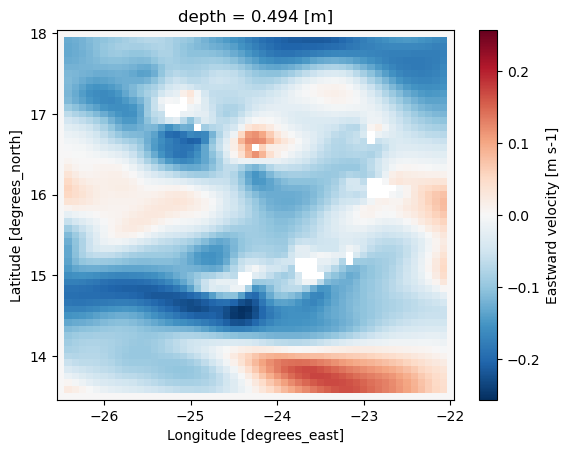

In [6]:
flowfield_env.uo.mean("time").plot()

In [7]:
variables = {
    "U": "uo",
    "V": "vo",
}

In [8]:
dimensions = {
    "lon": "longitude",
    "lat": "latitude",
    "time": "time"
}

In [9]:
fieldset = parcels.FieldSet.from_xarray_dataset(flowfield_env, variables, dimensions)

In [10]:
print(fieldset)

<FieldSet>
    fields:
        <Field>
            name            : 'U'
            grid            : RectilinearZGrid(lon=array([-26.50, -26.42, -26.33, ..., -22.17, -22.08, -22.00], shape=(55,), dtype=float32), lat=array([ 13.50,  13.58,  13.67, ...,  17.83,  17.92,  18.00], shape=(55,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00], shape=(31,)), time_origin=2025-08-01T00:00:00.000000000, mesh='spherical')
            extrapolate time: False
            time_periodic   : False
            gridindexingtype: 'nemo'
            to_write        : False
        <Field>
            name            : 'V'
            grid            : RectilinearZGrid(lon=array([-26.50, -26.42, -26.33, ..., -22.17, -22.08, -22.00], shape=(55,), dtype=float32), lat=array([ 13.50,  13.58,  13.67, ...,  17.83,  17.92,  18.00], shape=(55,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00], shape=(31,)),

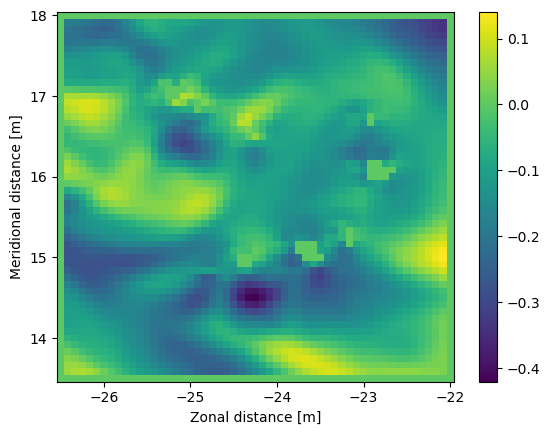

In [11]:
fieldset.computeTimeChunk()

plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[0, :, :])
plt.xlabel("Zonal distance [m]")
plt.ylabel("Meridional distance [m]")
plt.colorbar()
plt.show()

In [12]:
lon_grid = np.linspace(-26, -22.5, 100)
lat_grid = np.linspace(14, 17.5, 100)

In [13]:
delta = 0.02

In [14]:
lons = []
lats = []

for lon in lon_grid:
    for lat in lat_grid:

        lons.append(lon)
        lats.append(lat)

        lons.append(lon + delta)
        lats.append(lat)

        lons.append(lon)
        lats.append(lat + delta)

In [15]:
pset = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon=lons,
    lat=lats
)

In [16]:
print(pset)

<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : RectilinearZGrid(lon=array([-26.50, -26.42, -26.33, ..., -22.17, -22.08, -22.00], shape=(55,), dtype=float32), lat=array([ 13.50,  13.58,  13.67, ...,  17.83,  17.92,  18.00], shape=(55,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00], shape=(31,)), time_origin=2025-08-01T00:00:00.000000000, mesh='spherical')
                    extrapolate time: False
                    time_periodic   : False
                    gridindexingtype: 'nemo'
                    to_write        : False
                <Field>
                    name            : 'V'
                    grid            : RectilinearZGrid(lon=array([-26.50, -26.42, -26.33, ..., -22.17, -22.08, -22.00], shape=(55,), dtype=float32), lat=array([ 13.50,  13.58,  13.67, ...,  17.83,  17.92,  18.00], sh

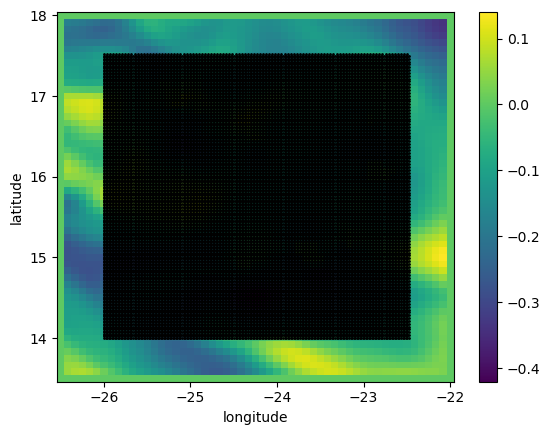

In [17]:
plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[0, :, :])
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.colorbar()

plt.plot(pset.lon, pset.lat, "ko", markersize=1)
plt.show()

In [18]:
output_file = pset.ParticleFile(
    name="CV_gridParticles.zarr",  # the file name
    outputdt=timedelta(hours=1),  # the time step of the outputs
)

print(output_file)

ParticleFile(name='CV_gridParticles.zarr', particleset=<parcels.particleset.ParticleSet object at 0x1554cc771d30>, outputdt=3600.0, chunks=None, create_new_zarrfile=True)


In [19]:
# Recovery kernels
def CheckOutOfBounds(particle, fieldset, time):
    if particle.state == StatusCode.ErrorOutOfBounds:
        particle.delete()

def CheckError(particle, fieldset, time):
    if particle.state >= 50:
        particle.delete()

# Build kernel
kernels = (
    pset.Kernel(parcels.AdvectionRK4)
    + pset.Kernel(CheckOutOfBounds)
)

# Execute
pset.execute(
    kernels,
    runtime=timedelta(days=10),
    dt=timedelta(minutes=5),
    #output_file=output_file,
)

100%|██████████| 864000.0/864000.0 [00:43<00:00, 19927.08it/s]


<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : RectilinearZGrid(lon=array([-26.50, -26.42, -26.33, ..., -22.17, -22.08, -22.00], shape=(55,), dtype=float32), lat=array([ 13.50,  13.58,  13.67, ...,  17.83,  17.92,  18.00], shape=(55,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00], shape=(31,)), time_origin=2025-08-01T00:00:00.000000000, mesh='spherical')
                    extrapolate time: False
                    time_periodic   : False
                    gridindexingtype: 'nemo'
                    to_write        : False
                <Field>
                    name            : 'V'
                    grid            : RectilinearZGrid(lon=array([-26.50, -26.42, -26.33, ..., -22.17, -22.08, -22.00], shape=(55,), dtype=float32), lat=array([ 13.50,  13.58,  13.67, ...,  17.83,  17.92,  18.00], sh

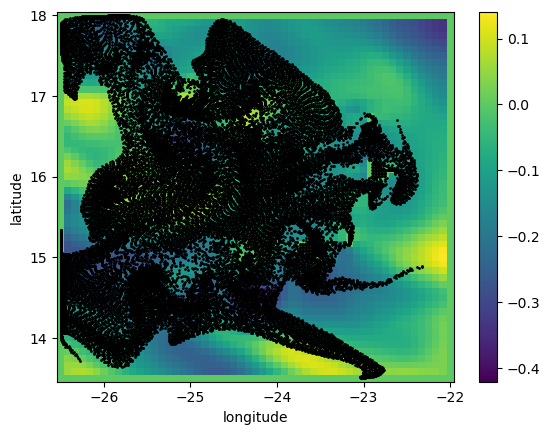

In [20]:
print(pset)

plt.pcolormesh(fieldset.U.grid.lon, fieldset.U.grid.lat, fieldset.U.data[0, :, :])
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.colorbar()

plt.plot(pset.lon, pset.lat, "ko", markersize = 1)
plt.show()

In [21]:
final_lon = pset.lon
final_lon

array([-26.280943, -26.289297, -26.335733, ..., -22.57997 , -22.594498,
       -22.61965 ], shape=(30000,), dtype=float32)

In [22]:
final_lat = pset.lat
final_lat

array([13.720183, 13.737081, 13.784253, ..., 16.59273 , 16.635113,
       16.70863 ], shape=(30000,), dtype=float32)

In [23]:
center = []
xshift = []
yshift = []

for i in range(0, len(final_lon), 3):
    center.append([final_lon[i], final_lat[i]])
    xshift.append([final_lon[i+1], final_lat[i+1]])
    yshift.append([final_lon[i+2], final_lat[i+2]])

center = np.array(center)
xshift = np.array(xshift)
yshift = np.array(yshift)

In [24]:
len(final_lon)

30000

In [25]:
len(final_lat)

30000

In [26]:
dXdx = (xshift[:,0] - center[:,0]) / delta
dYdx = (xshift[:,1] - center[:,1]) / delta

dXdy = (yshift[:,0] - center[:,0]) / delta
dYdy = (yshift[:,1] - center[:,1]) / delta

In [27]:
dXdx.shape

(10000,)

In [28]:
F = np.array([
    [dXdx, dXdy],
    [dYdx, dYdy]
])

In [29]:
print(F)

[[[-0.41770935 -0.5789757  -0.253582   ... -0.17986298 -0.47664642
   -0.7264137 ]
  [-2.7395248  -3.3307076  -0.8870125  ... -1.7987251  -2.2545815
   -1.984024  ]]

 [[ 0.8448601   0.931406    0.6901264  ...  1.4001846   1.6799927
    2.1191597 ]
  [ 3.2034874   3.025341    2.3022652  ...  5.464363    5.7253838
    5.795002  ]]]


In [30]:
F.shape

(2, 2, 10000)

In [31]:
C = np.einsum("kil,kjl->ijl",F,F)
C

array([[[ 0.88826966,  1.20273   ,  0.5405783 , ...,  1.9928677 ,
          3.0495672 ,  5.018515  ],
        [ 3.8508239 ,  4.7462196 ,  1.8137845 , ...,  7.9746413 ,
         10.693241  , 13.721757  ]],

       [[ 3.8508239 ,  4.7462196 ,  1.8137845 , ...,  7.9746413 ,
         10.693241  , 13.721757  ],
        [17.767328  , 20.2463    ,  6.0872164 , ..., 33.094677  ,
         37.863155  , 37.5184    ]]], shape=(2, 2, 10000), dtype=float32)

In [32]:
C_T = np.transpose(C, (2, 0, 1))
C_T

array([[[ 0.88826966,  3.8508239 ],
        [ 3.8508239 , 17.767328  ]],

       [[ 1.20273   ,  4.7462196 ],
        [ 4.7462196 , 20.2463    ]],

       [[ 0.5405783 ,  1.8137845 ],
        [ 1.8137845 ,  6.0872164 ]],

       ...,

       [[ 1.9928677 ,  7.9746413 ],
        [ 7.9746413 , 33.094677  ]],

       [[ 3.0495672 , 10.693241  ],
        [10.693241  , 37.863155  ]],

       [[ 5.018515  , 13.721757  ],
        [13.721757  , 37.5184    ]]], shape=(10000, 2, 2), dtype=float32)

In [33]:
eigenvalues, eigenvectors = np.linalg.eig(C_T)

In [34]:
eigenvalues

array([[5.1242523e-02, 1.8604355e+01],
       [8.5389480e-02, 2.1363640e+01],
       [1.2115496e-04, 6.6276736e+00],
       ...,
       [6.7344241e-02, 3.5020199e+01],
       [2.7414050e-02, 4.0885307e+01],
       [8.3010070e-07, 4.2536911e+01]], shape=(10000, 2), dtype=float32)

In [35]:
eigenvectors

array([[[-0.9771821 , -0.21240336],
        [ 0.21240336, -0.9771821 ]],

       [[-0.9733905 , -0.2291526 ],
        [ 0.2291526 , -0.9733905 ]],

       [[-0.95835954, -0.2855644 ],
        [ 0.2855644 , -0.95835954]],

       ...,

       [[-0.97206527, -0.2347108 ],
        [ 0.2347108 , -0.97206527]],

       [[-0.96230584, -0.27196953],
        [ 0.27196953, -0.96230584]],

       [[-0.9391591 , -0.3434825 ],
        [ 0.3434825 , -0.9391591 ]]], shape=(10000, 2, 2), dtype=float32)

In [36]:
np.argmax(eigenvalues,axis=1).mean()

np.float64(0.5227)

In [37]:
eigenvectors[:,np.where(eigenvalues,axis=1),:][0]

TypeError: where() got an unexpected keyword argument 'axis'

In [39]:
ev_max = np.where((np.argmax(eigenvalues,axis=1) == 0)[:,np.newaxis], eigenvectors[:,0,:], eigenvectors[:,1,:])
ev_max

array([[ 0.21240336, -0.9771821 ],
       [ 0.2291526 , -0.9733905 ],
       [ 0.2855644 , -0.95835954],
       ...,
       [ 0.2347108 , -0.97206527],
       [ 0.27196953, -0.96230584],
       [ 0.3434825 , -0.9391591 ]], shape=(10000, 2), dtype=float32)

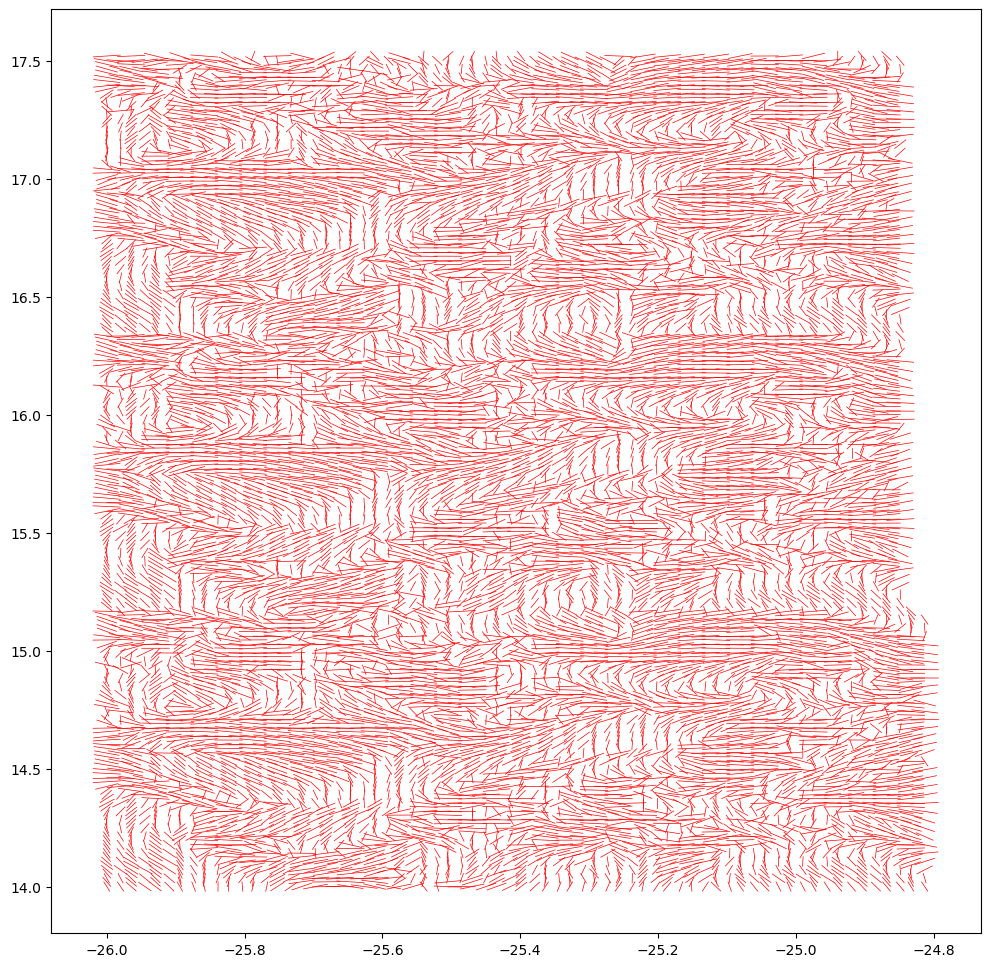

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
for n in range(10000):
    _x = [lons[n] + delta * ev_max[n, 0], lons[n] - delta * ev_max[n, 0]]
    _y = [lats[n] + delta * ev_max[n, 1], lats[n] - delta * ev_max[n, 1]]
    ax.plot(_x, _y, 'r-', linewidth=0.5, alpha=1)

In [41]:
max_eigenvalues = np.max(eigenvalues,axis=1)
max_eigenvalues

array([18.604355 , 21.36364  ,  6.6276736, ..., 35.0202   , 40.885307 ,
       42.53691  ], shape=(10000,), dtype=float32)

(array([9.659e+03, 1.600e+02, 7.300e+01, 4.500e+01, 2.500e+01, 1.100e+01,
        1.100e+01, 7.000e+00, 6.000e+00, 3.000e+00]),
 array([6.44814298e-02, 3.28542480e+02, 6.57020447e+02, 9.85498413e+02,
        1.31397644e+03, 1.64245447e+03, 1.97093237e+03, 2.29941040e+03,
        2.62788843e+03, 2.95636646e+03, 3.28484448e+03]),
 <BarContainer object of 10 artists>)

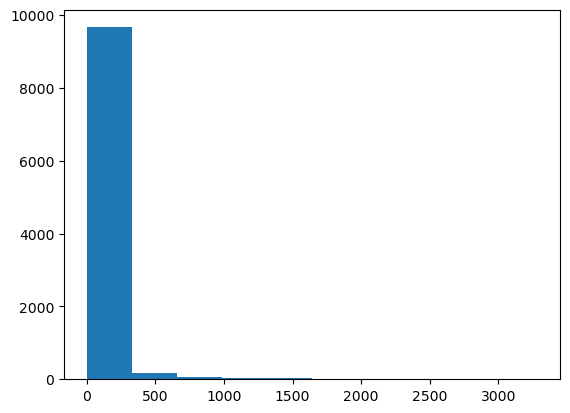

In [42]:
plt.hist(max_eigenvalues)

In [43]:
pd.Series(max_eigenvalues).quantile(np.linspace(0,1,31))

0.000000       0.064481
0.033333       0.694628
0.066667       1.225220
0.100000       1.645397
0.133333       2.006258
0.166667       2.354172
0.200000       2.698547
0.233333       3.049516
0.266667       3.443379
0.300000       3.916523
0.333333       4.468145
0.366667       5.074930
0.400000       5.746074
0.433333       6.412708
0.466667       7.270385
0.500000       8.316247
0.533333       9.347472
0.566667      10.567830
0.600000      12.209630
0.633333      13.912005
0.666667      16.204514
0.700000      19.004341
0.733333      22.363594
0.766667      27.175428
0.800000      33.418650
0.833333      42.479019
0.866667      56.518474
0.900000      81.884191
0.933333     133.795520
0.966667     334.522702
1.000000    3284.844482
dtype: float64

In [44]:
T = 10*24*60*60
T

864000

In [45]:
FTLE = (1/(2*T)) * np.log(max_eigenvalues)
FTLE

array([1.6917799e-06, 1.7718115e-06, 1.0944756e-06, ..., 2.0578268e-06,
       2.1474368e-06, 2.1703543e-06], shape=(10000,), dtype=float32)

In [46]:
len(lons)

30000

(array([  43.,  211.,  767., 2564., 2846., 1912.,  956.,  394.,  216.,
          91.]),
 array([-0.1370689 , -0.08287664, -0.02868439,  0.02550787,  0.07970013,
         0.13389239,  0.18808463,  0.24227691,  0.29646915,  0.3506614 ,
         0.4048537 ]),
 <BarContainer object of 10 artists>)

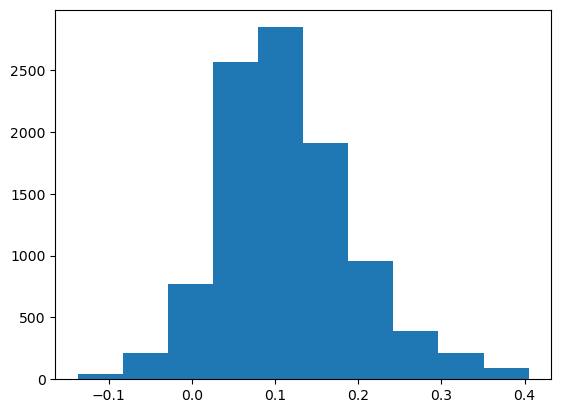

In [47]:
plt.hist(FTLE*3600*24)

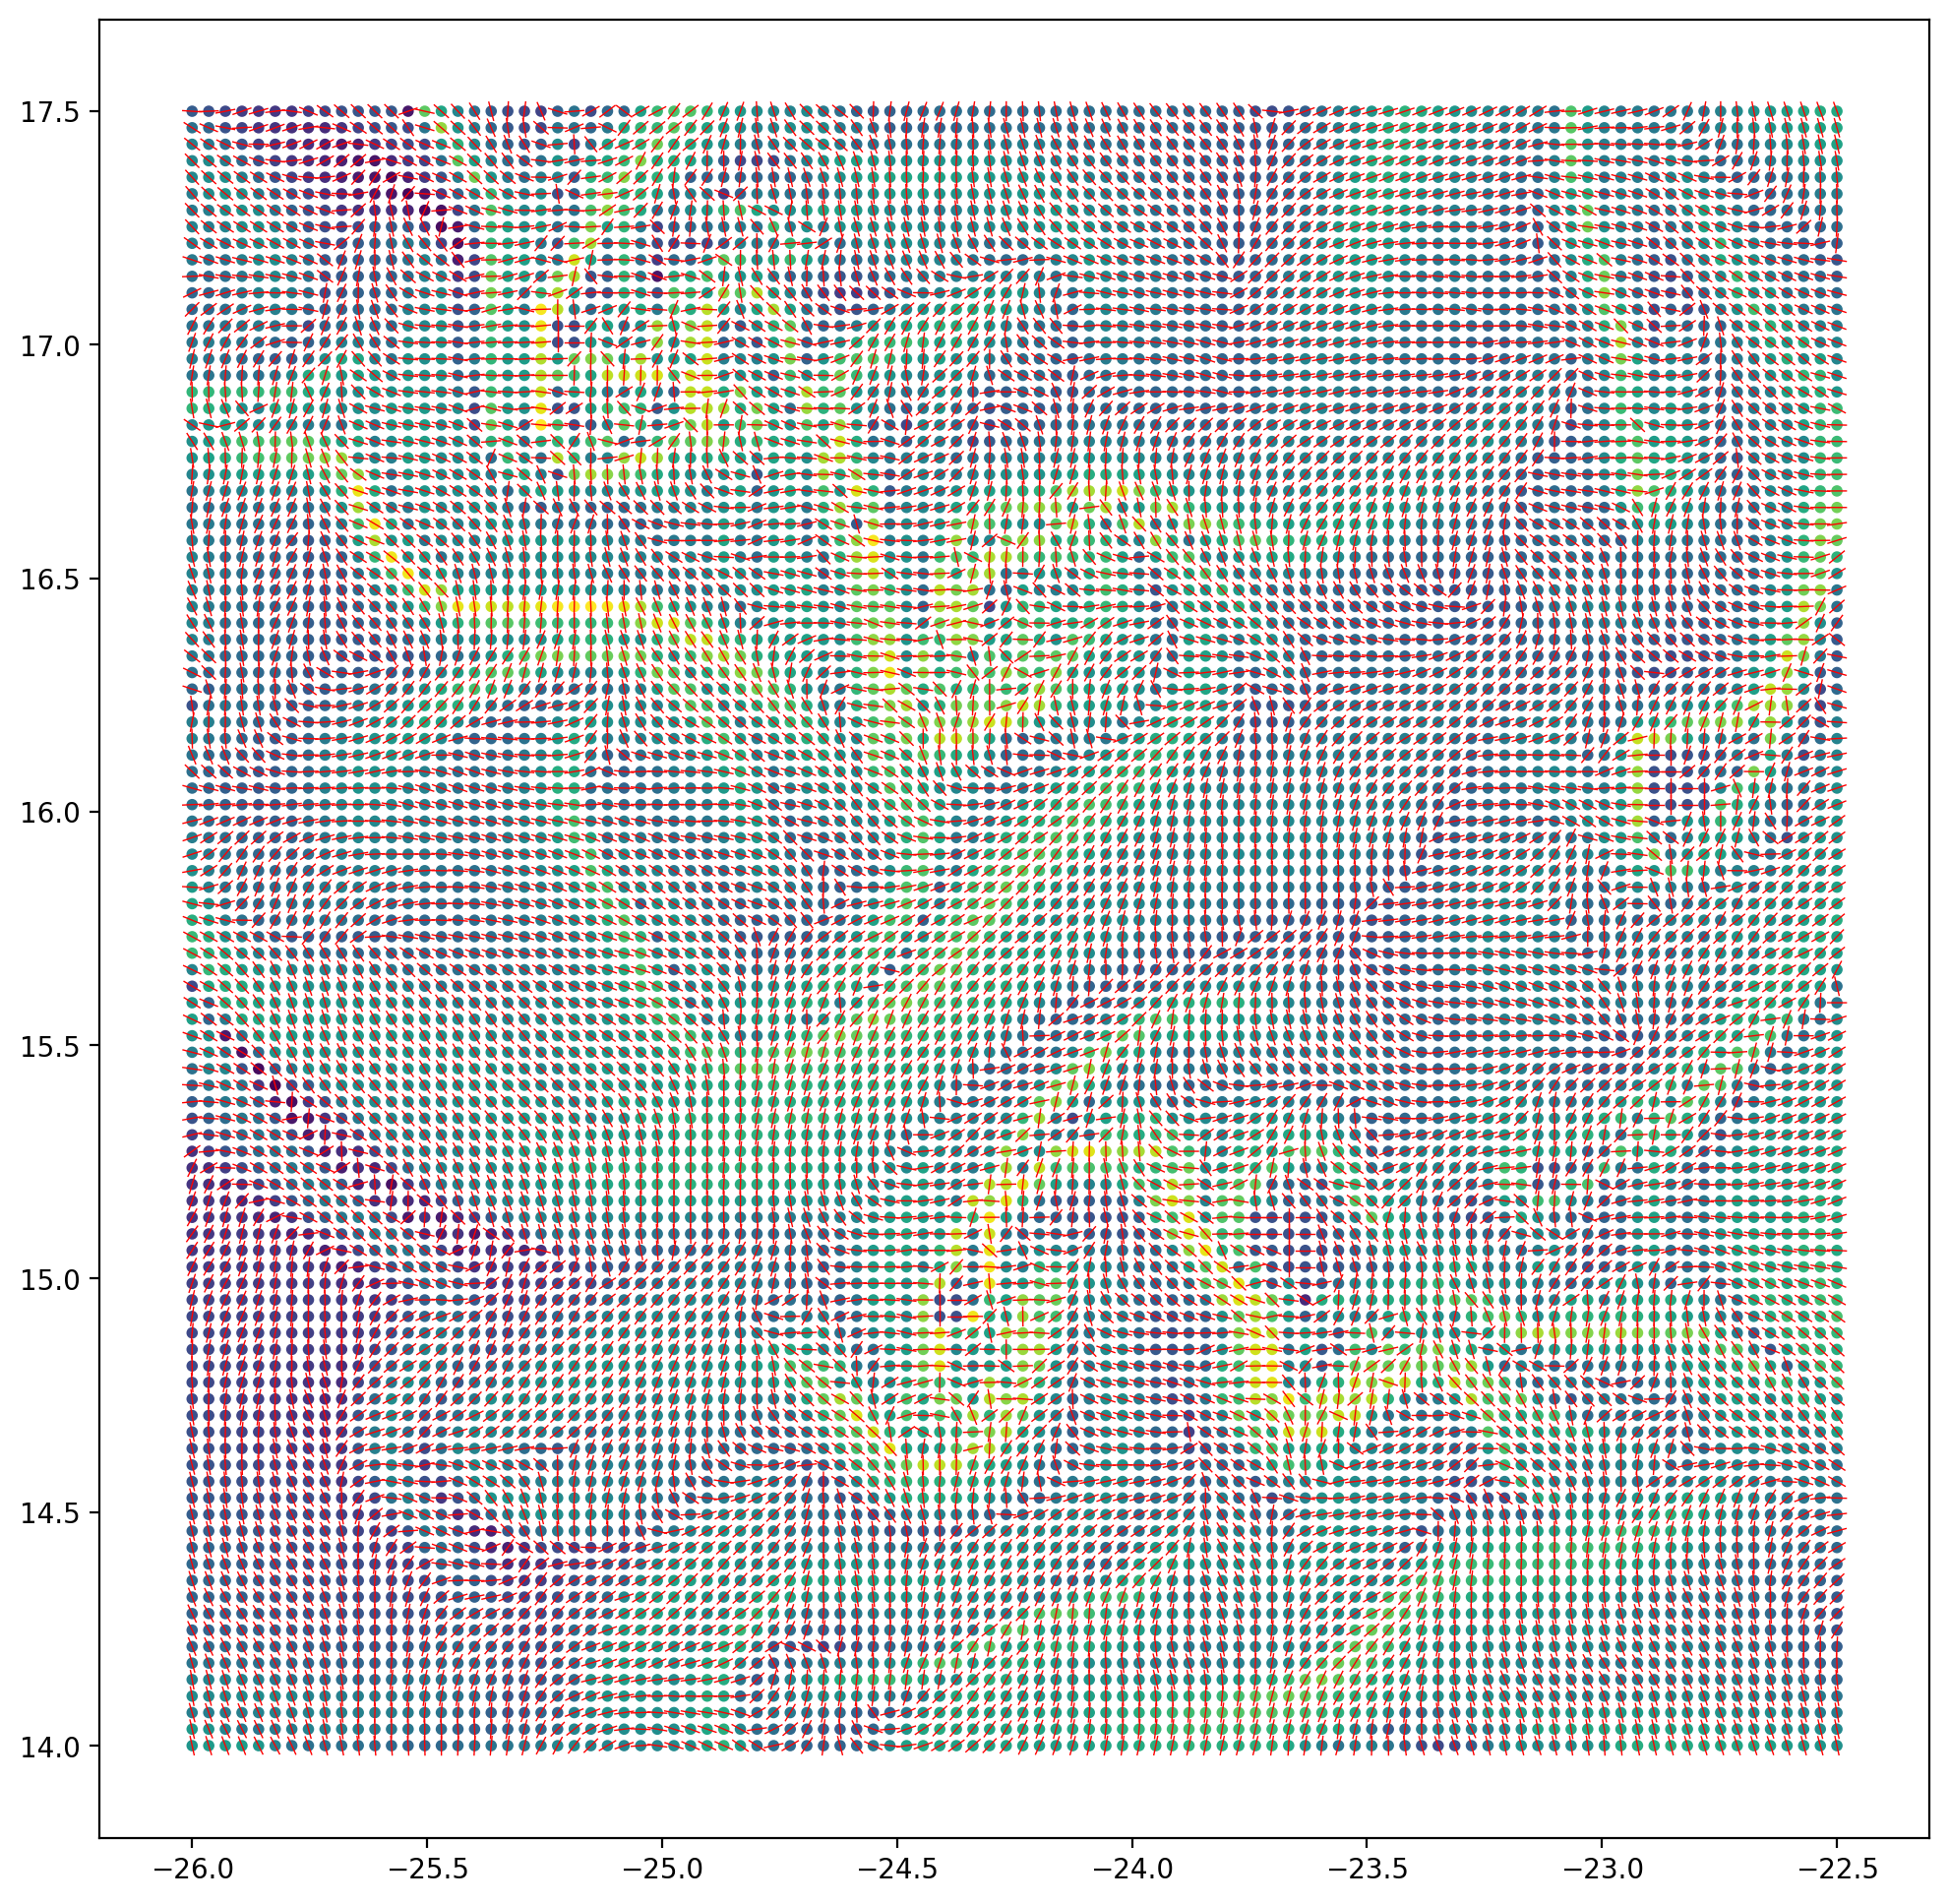

In [63]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

ax.scatter(lons[0::3], lats[0::3], 10, FTLE*24*3600)

for n in range(0,10000,1):
    _x = [lons[n*3] + delta * ev_max[n, 0], lons[n*3] - delta * ev_max[n, 0]]
    _y = [lats[n*3] + delta * ev_max[n, 1], lats[n*3] - delta * ev_max[n, 1]]
    ax.plot(_x, _y, 'r-', linewidth=0.5, alpha=1)

fig.set_dpi(200)
plt.show()

In [ ]:
ssh = ds.sea_surface_height
ssh

NameError: name 'ssh' is not defined

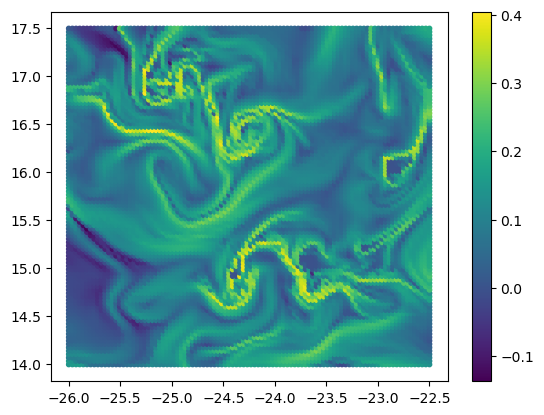

In [50]:
plt.scatter(lons[0::3], lats[0::3], 10, FTLE*24*3600)
plt.colorbar()
ssh.sel(time = "2025-08-01T00:00:00", method = "nearest", depth = 0).sel(longitude = slice(-27,-22), latitude = slice(13,18)).plot.contour(colors = "magenta")
ssh.sel(time = "2025-08-10T00:00:00", method = "nearest", depth = 0).sel(longitude = slice(-27,-22), latitude = slice(13,18)).plot.contour(colors = "cyan")